In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")


Libraries loaded successfully


# Retail Sales Performance — Exploratory Data Analysis
## Business Context
Analysing the Superstore dataset to identify revenue drivers, 
top customers, regional performance, and discount impact.

**Analyst:** Piumi Jayawardene  
**Date:** 2026 

**Dataset:** Sample Superstore (~10,000 orders, 2014–2017)

In [21]:
df = pd.read_csv("../data/raw/Sample - Superstore.csv", encoding="latin-1")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Rows: 9,994
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
print("Missing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nDuplicates:", df.duplicated().sum())

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Duplicates: 0


In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order YearMonth"] = df["Order Date"].dt.to_period("M")
print("Date columns fixed.")

Date columns fixed.


In [11]:
df.to_csv("../data/processed/superstore_clean.csv", index=False)
print("Cleaned data saved.")

Cleaned data saved.


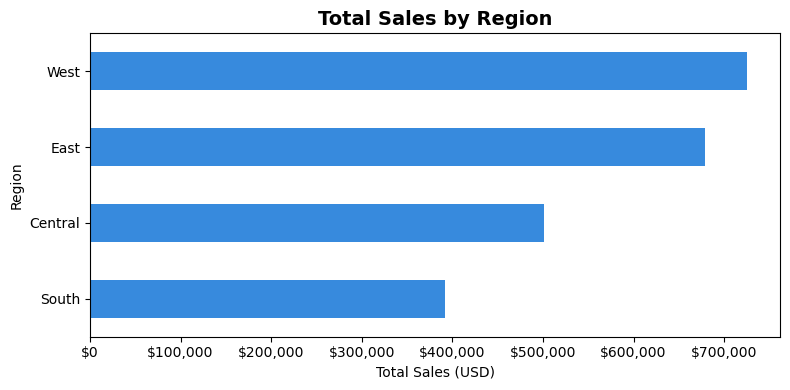

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
region_sales = df.groupby("Region")["Sales"].sum().sort_values()
region_sales.plot(kind="barh", ax=ax, color="#378ADD")
ax.set_title("Total Sales by Region", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Sales (USD)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("../dashboards/screenshots/chart1_region_sales.png", dpi=150)
plt.show()

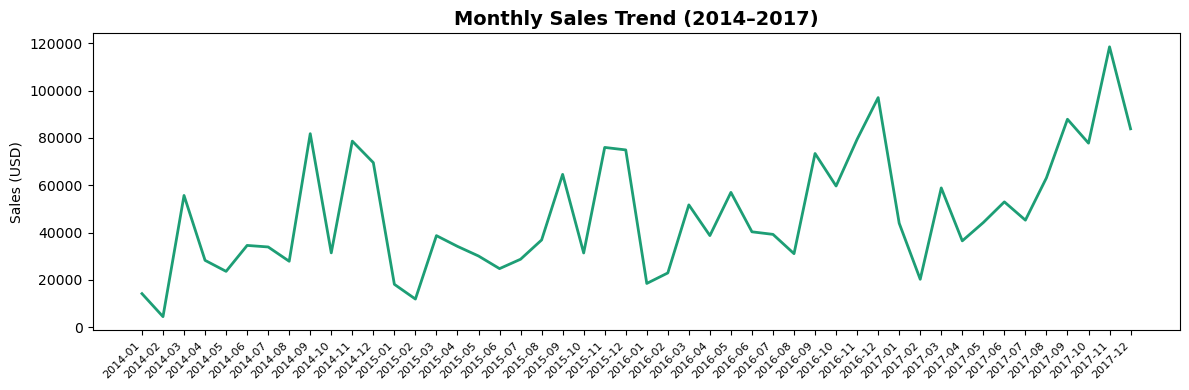

In [13]:
monthly = df.groupby("Order YearMonth")["Sales"].sum().reset_index()
monthly["Order YearMonth"] = monthly["Order YearMonth"].astype(str)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly["Order YearMonth"], monthly["Sales"], color="#1D9E75", linewidth=2)
ax.set_title("Monthly Sales Trend (2014–2017)", fontsize=14, fontweight="bold")
ax.set_ylabel("Sales (USD)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("../dashboards/screenshots/chart2_monthly_trend.png", dpi=150)
plt.show()

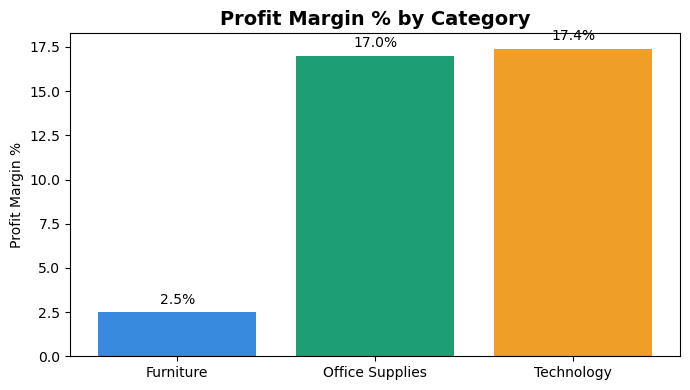

In [14]:
cat_perf = df.groupby("Category").agg(
    Total_Sales=("Sales","sum"),
    Total_Profit=("Profit","sum")
).reset_index()
cat_perf["Margin_Pct"] = (cat_perf["Total_Profit"]/cat_perf["Total_Sales"]*100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(cat_perf["Category"], cat_perf["Margin_Pct"],
             color=["#378ADD","#1D9E75","#EF9F27"])
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set_title("Profit Margin % by Category", fontsize=14, fontweight="bold")
ax.set_ylabel("Profit Margin %")
plt.tight_layout()
plt.savefig("../dashboards/screenshots/chart3_category_margin.png", dpi=150)
plt.show()

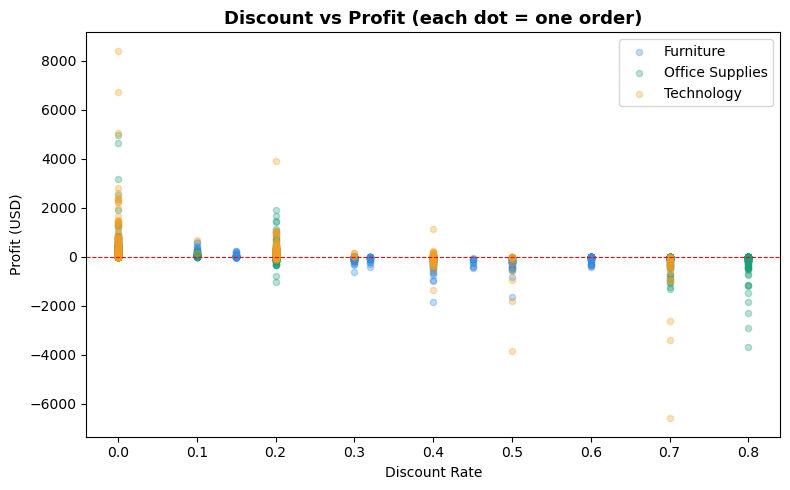

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"Furniture":"#378ADD","Office Supplies":"#1D9E75","Technology":"#EF9F27"}
for cat, grp in df.groupby("Category"):
    ax.scatter(grp["Discount"], grp["Profit"],
               alpha=0.3, s=20, label=cat, color=colors[cat])
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
ax.set_title("Discount vs Profit (each dot = one order)", fontsize=13, fontweight="bold")
ax.set_xlabel("Discount Rate")
ax.set_ylabel("Profit (USD)")
ax.legend()
plt.tight_layout()
plt.savefig("../dashboards/screenshots/chart4_discount_profit.png", dpi=150)
plt.show()

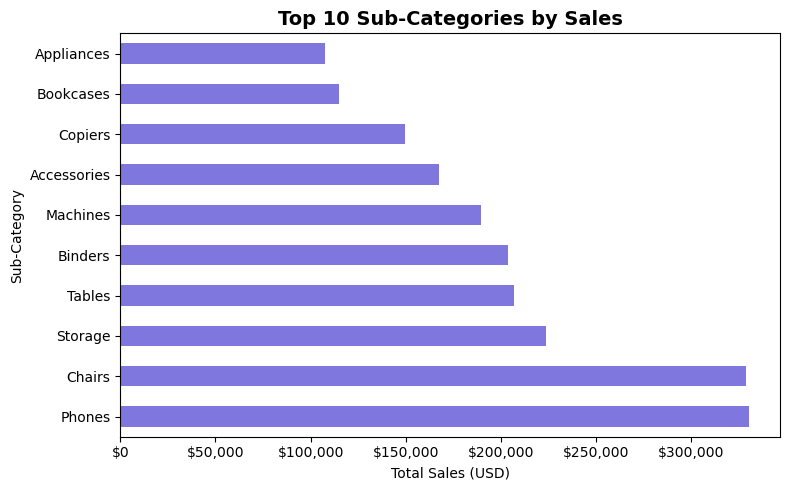

In [16]:
top_sub = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8, 5))
top_sub.plot(kind="barh", ax=ax, color="#7F77DD")
ax.set_title("Top 10 Sub-Categories by Sales", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Sales (USD)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("../dashboards/screenshots/chart5_subcategory_sales.png", dpi=150)
plt.show()

## Key Findings

1. **West region** leads in total sales, but **East region** 
   has a higher profit margin.
2. **Technology** is the most profitable category (avg margin ~17%), 
   while **Furniture** often sells at a loss.
3. Sales peak every **November–December** — seasonal buying pattern.
4. Orders with **>20% discount** almost always generate negative profit. 
   Discounting is hurting the business.
5. **Phones and Chairs** are the top revenue sub-categories, 
   but **Copiers** generate the highest profit per unit.

> Recommendation: Reduce discounts on Furniture. 
  Focus Q4 marketing on Technology products.

In [17]:
import os
print(os.getcwd())

C:\Users\piumi\retail-sales-dashboard\notebooks


In [18]:
import os

print(os.path.exists("../data/processed"))

True


In [19]:
import os

os.makedirs("../data/processed", exist_ok=True)

In [22]:
df.to_csv("../data/processed/superstore_clean.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [23]:
import os

print(os.listdir("../data/processed"))

['superstore_clean.csv']
